<span style = "font-family: Verdana; font-size: 20px">

#### **Feature Engineering**
</span>

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split  

from statsmodels.stats.outliers_influence import variance_inflation_factor    # call xong k dung`?
from statsmodels.tools.tools import add_constant    # call xong k dung`?

from sklearn.metrics import accuracy_score, classification_report, f1_score, log_loss   # call xong k dung`?
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

In [47]:
df = pd.read_csv("data/modified/viz_pokemon.csv", keep_default_na = False)
combats_df = pd.read_csv('data/raw_data/combats.csv')
combats_df.drop_duplicates()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  800 non-null    int64  
 1   Name                800 non-null    object 
 2   Type1               800 non-null    object 
 3   Type2               800 non-null    object 
 4   HiddenAbility       800 non-null    object 
 5   Generation          800 non-null    int64  
 6   Hp                  800 non-null    float64
 7   Attack              800 non-null    float64
 8   Defense             800 non-null    float64
 9   SpecialAttack       800 non-null    float64
 10  SpecialDefense      800 non-null    float64
 11  Speed               800 non-null    float64
 12  TotalStats          800 non-null    float64
 13  Weight              800 non-null    float64
 14  Height              800 non-null    float64
 15  GenderProbM         800 non-null    float64
 16  Category

<span style = "font-family: Verdana; font-size: 20px">

Dummify cột `Type1` và `Type2`
</span>

In [48]:
type1dum = pd.get_dummies(df['Type1'], prefix='Type', dtype=int)
type2dum = pd.get_dummies(df['Type2'], prefix='Type', dtype=int)

dummies_total = type1dum.add(type2dum, fill_value=0)
df = pd.concat([df, dummies_total], axis=1)
df = df.drop(['Type1', 'Type2'], axis=1)

<span style = "font-family: Verdana; font-size: 20px">

Chuyển `LevelingRate` thành các giá trị số tương ứng để sử dụng trong mô hình ML.

[Nguồn tham khảo](https://bulbapedia.bulbagarden.net/wiki/Experience)
</span>

In [49]:
df['LevelingRate'] = df['LevelingRate'].replace(['Slow', 'Medium Slow', 'Medium Fast', 'Fast', 'Erratic', 'Fluctuating'], [1250000, 1059860, 1000000, 800000, 600000, 1640000]).infer_objects(copy=False)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_5600\1293140977.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['LevelingRate'] = df['LevelingRate'].replace(['Slow', 'Medium Slow', 'Medium Fast', 'Fast', 'Erratic', 'Fluctuating'], [1250000, 1059860, 1000000, 800000, 600000, 1640000]).infer_objects(copy=False)


<div style="font-family: Verdana; font-size: 20px;">

<h3><strong>Tạo các biến chỉ số nội tại (Intrinsic Metrics) của từng Pokemon</strong></h3>

<h4><b>I. Khả Năng Tấn Công và Tốc Độ (<em>Offensive Power &amp; Speed</em>)</h4>

<table border="1" style="border-collapse: collapse; width: 100%;">
    <thead>
        <tr>
            <th>Biến Feature</th>
            <th>Mục đích</th>
            <th>Cách giúp dự đoán</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>Alpha_Strike</strong></td>
            <td>Chỉ số tấn công mạnh nhất (<em>Max(Atk, Sp.Atk)</em>). Đầu vào cơ sở cho tất cả các tính toán sát thương.</td>
            <td>Nếu P1 có <strong>Sweeper_Rating</strong> cao hơn, P1 có khả năng kết thúc trận đấu sớm trước khi P2 kịp phản công.</td>
        </tr>
        <tr>
            <td><strong>Sweeper_Rating</strong></td>
            <td>Đánh giá khả năng <em>"Quét team"</em> (<em>Speed × Alpha</em>).</td>
            <td>Pokémon nhanh với rating cao thường lợi thế lớn, đặc biệt trong trận đấu kết thúc nhanh.</td>
        </tr>
        <tr>
            <td><strong>Stat_Optimization</strong></td>
            <td>Mức độ dồn chỉ số tấn công theo một hướng (Vật lý hoặc Phép).</td>
            <td>Giúp mô hình phân biệt Pokémon tối ưu dame (tập trung) với Pokémon phân tán chỉ số (kém hiệu quả).</td>
        </tr>
    </tbody>
</table>


<h4><b>II. Khả Năng Phòng Thủ và Rủi Ro (<em>Defense &amp; Risk</em>)</h4>

<table border="1" style="border-collapse: collapse; width: 100%;">
    <thead>
        <tr>
            <th>Biến Feature</th>
            <th>Mục đích</th>
            <th>Cách giúp dự đoán</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>Durability_Score</strong></td>
            <td>Chỉ số bền bỉ tổng thể (<em>HP × Tổng Def</em>).</td>
            <td>Nếu P1 có điểm này vượt trội, P1 có lợi trong trận chiến kéo dài (<em>Attrition</em>).</td>
        </tr>
        <tr>
            <td><strong>Tank_Bias</strong></td>
            <td>Tỷ lệ % chỉ số phân bổ cho phòng thủ.</td>
            <td>Giúp mô hình nhận diện vai trò (Tank, Wall), từ đó dự đoán hành vi và lợi thế trận đấu.</td>
        </tr>
        <tr>
            <td><strong>Type_Vulnerability</strong></td>
            <td>Mức độ bị khắc chế (tổng hệ số sát thương &gt; 1.0).</td>
            <td>Nếu P1 có chỉ số này thấp hơn P2, P1 có lợi thế về phòng thủ hệ.</td>
        </tr>
        <tr>
            <td><strong>Insta_Kill_Risk</strong></td>
            <td>Nguy cơ bị hạ gục tức thì (<em>đếm số khắc chế 4×</em>).</td>
            <td>Nếu P2 có risk cao, P1 có thể thắng dễ dàng hơn nhiều.</td>
        </tr>
    </tbody>
</table>


<h4><b>III. Vai Trò và Hiệu Quả (<em>Role &amp; Utility</em>)</h4>

<table border="1" style="border-collapse: collapse; width: 100%;">
    <thead>
        <tr>
            <th>Biến Feature</th>
            <th>Mục đích</th>
            <th>Cách giúp dự đoán</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>Glass_Cannon_Index</strong></td>
            <td>Tỷ lệ <em>Offense / Defense</em>.</td>
            <td>Tránh mô hình nhầm lẫn Pokémon <em>máu giấy nhưng damage to</em> với Pokémon <em>phòng thủ trâu</em>.</td>
        </tr>
        <tr>
            <td><strong>Versatility_Bonus</strong></td>
            <td>Lợi thế đa hệ (<em>Dual Type</em>).</td>
            <td>Dual Type tăng khả năng kháng + damage STAB linh hoạt → giúp Pokémon thích ứng tốt hơn.</td>
        </tr>
        <tr>
            <td><strong>Legendary_Factor</strong></td>
            <td>Hệ số Pokémon Huyền Thoại/Mega.</td>
            <td>Tính đến lợi thế ẩn (Ability, Movepool…) mà chỉ số gốc không thể hiện hết.</td>
        </tr>
    </tbody>
</table>

</div>


In [50]:
def create_feature(df):
    # --- Alpha Strike (Sức Tấn Công Tối Ưu) ---
    # Logic: A Pokemon only attacks with its stronger stat. The other is irrelevant.
    df['Alpha_Strike'] = df[['Attack', 'SpecialAttack']].max(axis=1)

    # --- Durability Score (Khả Năng Chịu Đựng) ---
    # Formula: HP * (Defense + Sp.Defense) / 100
    # Logic: HP is volume, Defense is density. Effective Health = Volume * Density.
    # Measures how much total punishment a Pokemon can take before fainting.
    df['Durability_Score'] = (df['Hp'] * (df['Defense'] + df['SpecialDefense'])) / 100

    # --- Sweeper Rating (Chỉ Số Quét Team) ---
    # Formula: (Speed * Alpha_Strike) / 1000
    # Logic: High damage is useless if you are slow. High speed is useless if you deal no damage.
    df['Sweeper_Rating'] = (df['Speed'] * df['Alpha_Strike']) / 1000

    # --- Glass Cannon Index (Chỉ Số "Máu Giấy") ---
    # Formula: Alpha_Strike / (Defense + SpecialDefense)
    # Logic: High Value = Hits hard but dies fast. Low Value = Hits soft but never dies.
    # Helps the model distinguish between "Assassins" and "Tanks".
    df['Glass_Cannon_Index'] = df['Alpha_Strike'] / (df['Defense'] + df['SpecialDefense'] + 1)

    # --- Type Vulnerability (Tổng Mức Độ Bị Khắc Chế) ---
    # Formula: Sum of all 'DamageFrom...' columns where value > 1.0
    # Logic: Counts how many elemental types deal bonus damage to this Pokemon.
    # Higher score = More weaknesses = Bad.
    dmg_cols = [c for c in df.columns if c.startswith('DamageFrom')]
    df['Type_Vulnerability'] = df[dmg_cols].apply(lambda row: sum(x for x in row if x > 1.0), axis=1)

    # ---  Insta-Kill Risk (Nguy Cơ Tử Huyệt) ---
    # Formula: Count of types that deal >= 4.0x damage.
    # Logic: Taking 2x damage is manageable. Taking 4x damage is usually an instant loss (One-Shot).
    # This is a "Critical Risk" flag.
    df['Insta_Kill_Risk'] = (df[dmg_cols] >= 4.0).sum(axis=1)

    # --- Stat Optimization (Hiệu Quả Phân Phối Chỉ Số) ---
    # Formula: Alpha_Strike / (Attack + SpecialAttack)
    # Logic: Range 0.5 to 1.0.
    # 1.0 means the Pokemon puts ALL offensive stats into one basket (Optimal).
    # 0.5 means it splits stats evenly (Inefficient/Wasted potential).
    df['Stat_Optimization'] = df['Alpha_Strike'] / (df['Attack'] + df['SpecialAttack'] + 1)

    # --- Tank Bias (Thiên Hướng Phòng Thủ) ---
    # Formula: (Defense + Sp.Def) / TotalStats
    # Logic: What % of this Pokemon's total power is dedicated to surviving?
    # Helps cluster Pokemon into roles (Attacker vs Defender).
    df['Tank_Bias'] = (df['Defense'] + df['SpecialDefense']) / df['TotalStats']

    # --- Versatility Bonus (Lợi Thế Đa Hệ) ---
    # Formula: 1 if Type 2 exists, else 0.
    # Logic: Dual-type Pokemon have more "STAB" (Same Type Attack Bonus) options.
    # They can hit more enemies with bonus damage.
    type_cols = [c for c in df.columns if c.startswith('Type_')]
    df['Versatility_Bonus'] = df[type_cols].sum(axis=1).apply(lambda x: 1 if x > 1 else 0)

    # --- Legendary Factor (Hệ Số Huyền Thoại) ---
    # Formula: IsLegendary + IsMythical + IsMega
    # Logic: These Pokemon often have hidden advantages (Abilities, Movepools)
    # that raw stats don't fully capture.
    df['Legendary_Factor'] = df['IsLegendary'] + df['IsMythical'] + df['HasMega']
    
    cols_to_drop_safe = [col for col in df.columns if col.startswith('DamageFrom')]
    df.drop(columns=cols_to_drop_safe, inplace=True)

    return df

df = create_feature(df)

Xoá bỏ các cột chứa thông tin không giúp ích cho việc dự đoán kết quả chiến thắng của Pokemon. Các cột được loại bỏ liên quan đến các thông tin sơ bộ về Pokemon (chỉ số nội tại), thông tin có thể gây leakage

In [51]:
drop_cols = [
    'PreevoName', 'FightsWon', 'TotalFights', 'WinPercentage', 'HasMega', 'NoGender',
    'Weight', 'Height', 'GenderProbM', 'Category', 'CatchRate', 'EggCycles', 'BaseFriendship',
    'EggGroup1', 'EggGroup2'
]
df.drop(columns = drop_cols, inplace = True)

In [52]:
pd.set_option('display.max_columns', None)
df.head()

,ID,Name,HiddenAbility,Generation,Hp,Attack,Defense,SpecialAttack,SpecialDefense,Speed,TotalStats,LevelingRate,IsLegendary,IsMythical,EvoStage,TotalEvoStages,Ability1,Ability2,IsMega,Type_Bug,Type_Dark,Type_Dragon,Type_Electric,Type_Fairy,Type_Fighting,Type_Fire,Type_Flying,Type_Ghost,Type_Grass,Type_Ground,Type_Ice,Type_Normal,Type_Poison,Type_Psychic,Type_Rock,Type_Steel,Type_Water,Alpha_Strike,Durability_Score,Sweeper_Rating,Glass_Cannon_Index,Type_Vulnerability,Insta_Kill_Risk,Stat_Optimization,Tank_Bias,Versatility_Bonus,Legendary_Factor
0,1,Bulbasaur,Chlorophyll,1,45.0,49.0,49.0,65.0,65.0,45.0,318.0,1059860,0,0,1,3,Overgrow,None,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,65.0,51.30,2.925,0.565217,8.0,0,0.565217,0.358491,1,0
1,2,Ivysaur,Chlorophyll,1,60.0,62.0,63.0,80.0,80.0,60.0,405.0,1059860,0,0,2,3,Overgrow,None,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,80.0,85.80,4.800,0.555556,8.0,0,0.559441,0.353086,1,0
2,3,Venusaur,Chlorophyll,1,80.0,82.0,83.0,100.0,100.0,80.0,525.0,1059860,0,0,3,3,Overgrow,None,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,100.0,146.40,8.000,0.543478,8.0,0,0.546448,0.348571,1,1
3,4,Mega Venusaur,None,1,80.0,100.0,123.0,122.0,120.0,80.0,625.0,1059860,0,0,3,3,Thick Fat,None,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,122.0,194.40,9.760,0.500000,4.0,0,0.547085,0.388800,1,1
4,5,Charmander,Solar Power,1,39.0,52.0,43.0,60.0,50.0,65.0,309.0,1059860,0,0,1,3,Blaze,None,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,60.0,36.27,3.900,0.638298,6.0,0,0.530973,0.300971,1,0


In [53]:
stats_p1 = df.add_suffix('_P1')
stats_p2 = df.add_suffix('_P2')

# Merge cho Pokemon thứ nhất (First_pokemon)
final_df = pd.merge(
    combats_df,
    stats_p1,
    left_on='First_pokemon', 
    right_on='ID_P1',
    how='inner'
)

# Merge cho Pokemon thứ hai (Second_pokemon)
final_df = pd.merge(
    final_df,
    stats_p2,
    left_on='Second_pokemon', 
    right_on='ID_P2',
    how='inner'
)

# Tạo biến mục tiêu (P1 thắng = 1)
final_df['P1_Win'] = (final_df['Winner'] == final_df['First_pokemon']).astype(int)

final_df = final_df.drop(columns=['ID_P1', 'ID_P2', 'Winner', 'First_pokemon', 'Second_pokemon', 'Name_P1', 'Name_P2'])

In [54]:
final_df.shape

(50000, 91)

In [55]:
final_df.head()

,HiddenAbility_P1,Generation_P1,Hp_P1,Attack_P1,Defense_P1,SpecialAttack_P1,SpecialDefense_P1,Speed_P1,TotalStats_P1,LevelingRate_P1,IsLegendary_P1,IsMythical_P1,EvoStage_P1,TotalEvoStages_P1,Ability1_P1,Ability2_P1,IsMega_P1,Type_Bug_P1,Type_Dark_P1,Type_Dragon_P1,Type_Electric_P1,Type_Fairy_P1,Type_Fighting_P1,Type_Fire_P1,Type_Flying_P1,Type_Ghost_P1,Type_Grass_P1,Type_Ground_P1,Type_Ice_P1,Type_Normal_P1,Type_Poison_P1,Type_Psychic_P1,Type_Rock_P1,Type_Steel_P1,Type_Water_P1,Alpha_Strike_P1,Durability_Score_P1,Sweeper_Rating_P1,Glass_Cannon_Index_P1,Type_Vulnerability_P1,Insta_Kill_Risk_P1,Stat_Optimization_P1,Tank_Bias_P1,Versatility_Bonus_P1,Legendary_Factor_P1,HiddenAbility_P2,Generation_P2,Hp_P2,Attack_P2,Defense_P2,SpecialAttack_P2,SpecialDefense_P2,Speed_P2,TotalStats_P2,LevelingRate_P2,IsLegendary_P2,IsMythical_P2,EvoStage_P2,TotalEvoStages_P2,Ability1_P2,Ability2_P2,IsMega_P2,Type_Bug_P2,Type_Dark_P2,Type_Dragon_P2,Type_Electric_P2,Type_Fairy_P2,Type_Fighting_P2,Type_Fire_P2,Type_Flying_P2,Type_Ghost_P2,Type_Grass_P2,Type_Ground_P2,Type_Ice_P2,Type_Normal_P2,Type_Poison_P2,Type_Psychic_P2,Type_Rock_P2,Type_Steel_P2,Type_Water_P2,Alpha_Strike_P2,Durability_Score_P2,Sweeper_Rating_P2,Glass_Cannon_Index_P2,Type_Vulnerability_P2,Insta_Kill_Risk_P2,Stat_Optimization_P2,Tank_Bias_P2,Versatility_Bonus_P2,Legendary_Factor_P2,P1_Win
0,Sand Veil,2,50.0,64.0,50.0,45.0,50.0,41.0,300.0,1250000,0,0,1,3,Guts,None,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,64.0,50.00,2.624,0.633663,16.0,2,0.581818,0.333333,1,0,Pickpocket,3,70.0,70.0,40.0,60.0,40.0,60.0,340.0,1059860,0,0,2,3,Chlorophyll,Early Bird,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,70.0,56.0,4.200,0.864198,16.0,1,0.534351,0.235294,1,0,0
1,None,5,91.0,90.0,72.0,90.0,129.0,108.0,580.0,1250000,1,0,1,1,Justified,None,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,90.0,182.91,9.720,0.445545,14.0,1,0.497238,0.346552,1,1,None,5,91.0,129.0,90.0,72.0,90.0,108.0,580.0,1250000,1,0,1,1,Justified,None,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,129.0,163.8,13.932,0.712707,14.0,0,0.638614,0.310345,1,1,0
2,Super Luck,2,55.0,40.0,85.0,80.0,105.0,40.0,405.0,800000,0,0,2,3,Hustle,Serene Grace,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,80.0,104.50,3.200,0.418848,10.0,0,0.661157,0.469136,1,0,Analytic,5,75.0,75.0,75.0,125.0,95.0,40.0,485.0,1000000,0,0,2,2,Telepathy,Synchronize,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,125.0,127.5,5.000,0.730994,6.0,0,0.621891,0.350515,1,0,0
3,Weak Armor,2,40.0,40.0,40.0,70.0,40.0,20.0,250.0,1000000,0,0,1,2,Magma Armor,Flame Body,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,70.0,32.00,1.400,0.864198,6.0,0,0.630631,0.320000,1,0,Mold Breaker,5,77.0,120.0,90.0,60.0,90.0,48.0,485.0,1000000,0,0,1,1,Rough Skin,Sheer Force,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120.0,138.6,5.760,0.662983,6.0,0,0.662983,0.371134,1,0,0
4,Weak Armor,1,70.0,60.0,125.0,115.0,70.0,55.0,495.0,1000000,0,0,2,2,Swift Swim,Shell Armor,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,115.0,136.50,6.325,0.586735,10.0,1,0.653409,0.393939,1,0,Contrary,2,20.0,10.0,230.0,10.0,230.0,5.0,505.0,1059860,0,0,1,1,Sturdy,Gluttony,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,10.0,92.0,0.050,0.021692,6.0,0,0.476190,0.910891,1,0,1


### **Feature Engineering tạo các biến tương quan giữa Pokemon thứ nhất và thứ hai**

In [56]:
def create_feature(df):
    # Tấn công Vật lý vs Phòng thủ Vật lý (Physical Matchup)
    # Nếu lớn hơn 1: P1 có lợi thế
    df['Phys_Advantage_P1'] = df['Attack_P1'] / (df['Defense_P2']+ 0.1)
    df['Phys_Advantage_P2'] = df['Attack_P2'] / (df['Defense_P1']+ 0.1)

    # Tấn công Đặc biệt vs Phòng thủ Đặc biệt (Special Matchup)
    df['Spec_Advantage_P1'] = df['SpecialAttack_P1'] / (df['SpecialDefense_P2'] + 0.1)
    df['Spec_Advantage_P2'] = df['SpecialAttack_P2'] / (df['SpecialDefense_P1'] + 0.1)

    # Alpha Strike: Khả năng dồn dame nhanh
    df['Alpha_Diff'] = df['Alpha_Strike_P1'] - df['Alpha_Strike_P2']

    return df

In [57]:
# SPEED-BASED FEATURES =========================================

def add_speed_features(df):
    df['Speed_Difference'] = df['Speed_P1'] - df['Speed_P2']
    df['Speed_Ratio'] = df['Speed_P1'] / (df['Speed_P2'] + 1)
    
    df['P1_Much_Faster'] = (df['Speed_Ratio'] > 1.2).astype(int)  
    df['P2_Much_Faster'] = (df['Speed_Ratio'] < 0.8).astype(int)
    
    df['Speed_Tie'] = ((df['Speed_Ratio'] > 0.95) & (df['Speed_Ratio'] < 1.05)).astype(int)
    
    return df

In [58]:
# DEFENSIVE CAPABILITIES ==========================================

def add_defensive_features(df):
    df['P1_Physical_Bulk'] = df['Hp_P1'] * df['Defense_P1']
    df['P2_Physical_Bulk'] = df['Hp_P2'] * df['Defense_P2']
    
    df['P1_Special_Bulk'] = df['Hp_P1'] * df['SpecialDefense_P1']
    df['P2_Special_Bulk'] = df['Hp_P2'] * df['SpecialDefense_P2']
    
    df['P1_Overall_Bulk'] = (df['P1_Physical_Bulk'] + df['P1_Special_Bulk']) / 2
    df['P2_Overall_Bulk'] = (df['P2_Physical_Bulk'] + df['P2_Special_Bulk']) / 2
    
    df['Bulk_Advantage_P1'] = df['P1_Overall_Bulk'] / (df['P2_Overall_Bulk'] + 1)
    
    return df

In [59]:
def diff_features(df):    
    stats_cols = [
        'Hp', 'Defense', 'SpecialAttack', 'TotalStats',
        'SpecialDefense', 'Attack'
    ]

    for col in stats_cols:
        df[f'Diff_{col}'] = df[f'{col}_P1'] - df[f'{col}_P2']

        df.drop(columns=[f'{col}_P1', f'{col}_P2'], inplace=True)

    special_flags = ['IsLegendary', 'IsMythical']
    for col in special_flags:
        df[f'Diff_{col}'] = df[f'{col}_P1'] - df[f'{col}_P2']
        df.drop(columns=[f'{col}_P1', f'{col}_P2'], inplace=True)
    
    return df

In [60]:
def engineer_all_features(df):
    """Apply all feature engineering steps"""
    df = create_feature(df)
    df = add_speed_features(df)
    df = add_defensive_features(df)
    df = diff_features(df)
    
    return df

pokemon_df = engineer_all_features(final_df)

In [61]:
pd.set_option('display.max_columns', None)
pokemon_df.head()

,HiddenAbility_P1,Generation_P1,Speed_P1,LevelingRate_P1,EvoStage_P1,TotalEvoStages_P1,Ability1_P1,Ability2_P1,IsMega_P1,Type_Bug_P1,Type_Dark_P1,Type_Dragon_P1,Type_Electric_P1,Type_Fairy_P1,Type_Fighting_P1,Type_Fire_P1,Type_Flying_P1,Type_Ghost_P1,Type_Grass_P1,Type_Ground_P1,Type_Ice_P1,Type_Normal_P1,Type_Poison_P1,Type_Psychic_P1,Type_Rock_P1,Type_Steel_P1,Type_Water_P1,Alpha_Strike_P1,Durability_Score_P1,Sweeper_Rating_P1,Glass_Cannon_Index_P1,Type_Vulnerability_P1,Insta_Kill_Risk_P1,Stat_Optimization_P1,Tank_Bias_P1,Versatility_Bonus_P1,Legendary_Factor_P1,HiddenAbility_P2,Generation_P2,Speed_P2,LevelingRate_P2,EvoStage_P2,TotalEvoStages_P2,Ability1_P2,Ability2_P2,IsMega_P2,Type_Bug_P2,Type_Dark_P2,Type_Dragon_P2,Type_Electric_P2,Type_Fairy_P2,Type_Fighting_P2,Type_Fire_P2,Type_Flying_P2,Type_Ghost_P2,Type_Grass_P2,Type_Ground_P2,Type_Ice_P2,Type_Normal_P2,Type_Poison_P2,Type_Psychic_P2,Type_Rock_P2,Type_Steel_P2,Type_Water_P2,Alpha_Strike_P2,Durability_Score_P2,Sweeper_Rating_P2,Glass_Cannon_Index_P2,Type_Vulnerability_P2,Insta_Kill_Risk_P2,Stat_Optimization_P2,Tank_Bias_P2,Versatility_Bonus_P2,Legendary_Factor_P2,P1_Win,Phys_Advantage_P1,Phys_Advantage_P2,Spec_Advantage_P1,Spec_Advantage_P2,Alpha_Diff,Speed_Difference,Speed_Ratio,P1_Much_Faster,P2_Much_Faster,Speed_Tie,P1_Physical_Bulk,P2_Physical_Bulk,P1_Special_Bulk,P2_Special_Bulk,P1_Overall_Bulk,P2_Overall_Bulk,Bulk_Advantage_P1,Diff_Hp,Diff_Defense,Diff_SpecialAttack,Diff_TotalStats,Diff_SpecialDefense,Diff_Attack,Diff_IsLegendary,Diff_IsMythical
0,Sand Veil,2,41.0,1250000,1,3,Guts,None,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,64.0,50.00,2.624,0.633663,16.0,2,0.581818,0.333333,1,0,Pickpocket,3,60.0,1059860,2,3,Chlorophyll,Early Bird,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,70.0,56.0,4.200,0.864198,16.0,1,0.534351,0.235294,1,0,0,1.596010,1.397206,1.122195,1.197605,-6.0,-19.0,0.672131,0,1,0,2500.0,2800.0,2500.0,2800.0,2500.0,2800.0,0.892538,-20.0,10.0,-15.0,-40.0,10.0,-6.0,0,0
1,None,5,108.0,1250000,1,1,Justified,None,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,90.0,182.91,9.720,0.445545,14.0,1,0.497238,0.346552,1,1,None,5,108.0,1250000,1,1,Justified,None,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,129.0,163.8,13.932,0.712707,14.0,0,0.638614,0.310345,1,1,0,0.998890,1.789182,0.998890,0.557707,-39.0,0.0,0.990826,0,0,1,6552.0,8190.0,11739.0,8190.0,9145.5,8190.0,1.116530,0.0,-18.0,18.0,0.0,39.0,-39.0,0,0
2,Super Luck,2,40.0,800000,2,3,Hustle,Serene Grace,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,80.0,104.50,3.200,0.418848,10.0,0,0.661157,0.469136,1,0,Analytic,5,40.0,1000000,2,2,Telepathy,Synchronize,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,125.0,127.5,5.000,0.730994,6.0,0,0.621891,0.350515,1,0,0,0.532623,0.881316,0.841220,1.189343,-45.0,0.0,0.975610,0,0,1,4675.0,5625.0,5775.0,7125.0,5225.0,6375.0,0.819479,-20.0,10.0,-45.0,-80.0,10.0,-35.0,0,0
3,Weak Armor,2,20.0,1000000,1,2,Magma Armor,Flame Body,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,70.0,32.00,1.400,0.864198,6.0,0,0.630631,0.320000,1,0,Mold Breaker,5,48.0,1000000,1,1,Rough Skin,Sheer Force,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120.0,138.6,5.760,0.662983,6.0,0,0.662983,0.371134,1,0,0,0.443951,2.992519,0.776915,1.496259,-50.0,-28.0,0.408163,0,1,0,1600.0,6930.0,1600.0,6930.0,1600.0,6930.0,0.230847,-37.0,-50.0,10.0,-235.0,-50.0,-80.0,0,0
4,Weak Armor,1,55.0,1000000,2,2,Swift Swim,Shell Armor,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,115.0,136.50,6.325,0.586735,10.0,1,0.653409,0.393939,1,0,Contrary,2,5.0,1059860,1,1,Sturdy,Gluttony,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,10.0,92.0,0.050,0.021692,6.0,0,0.476190,0.910891,1,0,1,0.260756,0.079936,0.499783,0.142653,105.0,50.0,9.166667,1,0,0,8750.0,4600.0,4900.0,4600.0,6825.0,4600.0,1.483373,50.0,-105.0,105.0,-10.0,-160.0,50.0,0,0


In [62]:
pokemon_df.shape

(50000, 100)

Các cột Ability và HiddenAbility có kiểu dữ liệu object, cần chuyển thành dạng số để mô hình có thể đọc hiểu.
Chúng tôi sẽ scale các ability tuỳ theo mức độ mạnh yếu, và để không bị leakage cần chia train test trước khi xử lý các cột này

In [63]:
X = pokemon_df.drop(columns=['P1_Win'])
y = pokemon_df['P1_Win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Xử lý các cột Ability =========
train_p1 = X_train[['Ability1_P1', 'Ability2_P1', 'HiddenAbility_P1']].melt()['value']
train_p1_win = pd.concat([y_train]*3, ignore_index=True)

# Gom cả P2 của tập TRAIN (P2 thắng = y_train là 0)
train_p2 = X_train[['Ability1_P2', 'Ability2_P2', 'HiddenAbility_P2']].melt()['value']
train_p2_win = pd.concat([1 - y_train]*3, ignore_index=True)

all_train_abs = pd.concat([train_p1, train_p2])
all_train_wins = pd.concat([train_p1_win, train_p2_win])
temp_df = pd.DataFrame({'Ability': all_train_abs, 'Win': all_train_wins})

# Công thức: (Số trận thắng + alpha * trung bình toàn cục) / (Tổng số trận + alpha)
# Giúp các ability hiếm không bị điểm quá cao hoặc quá thấp
global_mean = all_train_wins.mean()
alpha = 10 # Trọng số làm mượt (giả định có sẵn 10 trận hòa để kéo về trung bình)

stats = temp_df.groupby('Ability')['Win'].agg(['sum', 'count'])
tier_dict = ((stats['sum'] + alpha * global_mean) / (stats['count'] + alpha)).to_dict()

expert_tier = {
    # S+ tier (0.97–0.99)
    'Wonder Guard': 0.99, 'Shadow Tag': 0.98, 'Arena Trap': 0.98, 'Huge Power': 0.98, 'Pure Power': 0.98,
    'Speed Boost': 0.98, 'Moody': 0.98, 'Imposter': 0.98, 'Drizzle': 0.97, 'Drought': 0.97,
    'Snow Warning': 0.97, 'Desolate Land': 0.97, 'Primordial Sea': 0.97,

    # S tier (0.90–0.96)
    'Protean': 0.96, 'Libero': 0.96, 'Intimidate': 0.94, 'Magic Guard': 0.93, 'Levitate': 0.92,
    'Regenerator': 0.92, 'Prankster': 0.91, 'Multiscale': 0.91, 'Fur Coat': 0.91,

    # A+ tier (0.85–0.89)
    'Swift Swim': 0.89, 'Chlorophyll': 0.89, 'Sand Rush': 0.89, 'Technician': 0.88,
    'Adaptability': 0.88, 'Guts': 0.87, 'Tough Claws': 0.87,

    'Slow Start': 0.15, 'Truant': 0.10, 'Defeatist': 0.20,
}
tier_dict.update(expert_tier)


# ÁP DỤNG CHO CẢ TRAIN VÀ TEST
def calculate_score(row, prefix, source_dict):
    abs_list = [
        row.get(f'Ability 1_{prefix}'),
        row.get(f'Ability 2_{prefix}'),
        row.get(f'HiddenAbility_{prefix}')
    ]
    scores = []
    for ab in abs_list:
        if pd.notna(ab):
            scores.append(source_dict.get(str(ab), global_mean))
            
    if not scores: return global_mean
    return max(scores)

# Áp dụng cho X_train
X_train['Ability_Score_P1'] = X_train.apply(lambda r: calculate_score(r, 'P1', tier_dict), axis=1)
X_train['Ability_Score_P2'] = X_train.apply(lambda r: calculate_score(r, 'P2', tier_dict), axis=1)
X_train['Ability_Diff'] = X_train['Ability_Score_P1'] - X_train['Ability_Score_P2']

# Áp dụng cho X_test (Dùng tier_dict CỦA TẬP TRAIN)
X_test['Ability_Score_P1'] = X_test.apply(lambda r: calculate_score(r, 'P1', tier_dict), axis=1)
X_test['Ability_Score_P2'] = X_test.apply(lambda r: calculate_score(r, 'P2', tier_dict), axis=1)
X_test['Ability_Diff'] = X_test['Ability_Score_P1'] - X_test['Ability_Score_P2']

cols_to_drop = [
    'Ability1_P1', 'Ability2_P1', 'HiddenAbility_P1',
    'Ability1_P2', 'Ability2_P2', 'HiddenAbility_P2'
]
X_train.drop(columns = cols_to_drop, inplace = True)
X_test.drop(columns = cols_to_drop, inplace = True)

In [64]:
print("Shape of X train: ", {X_train.shape})

Shape of X train:  {(37500, 96)}


**KIỂM TRA CORRELATION**

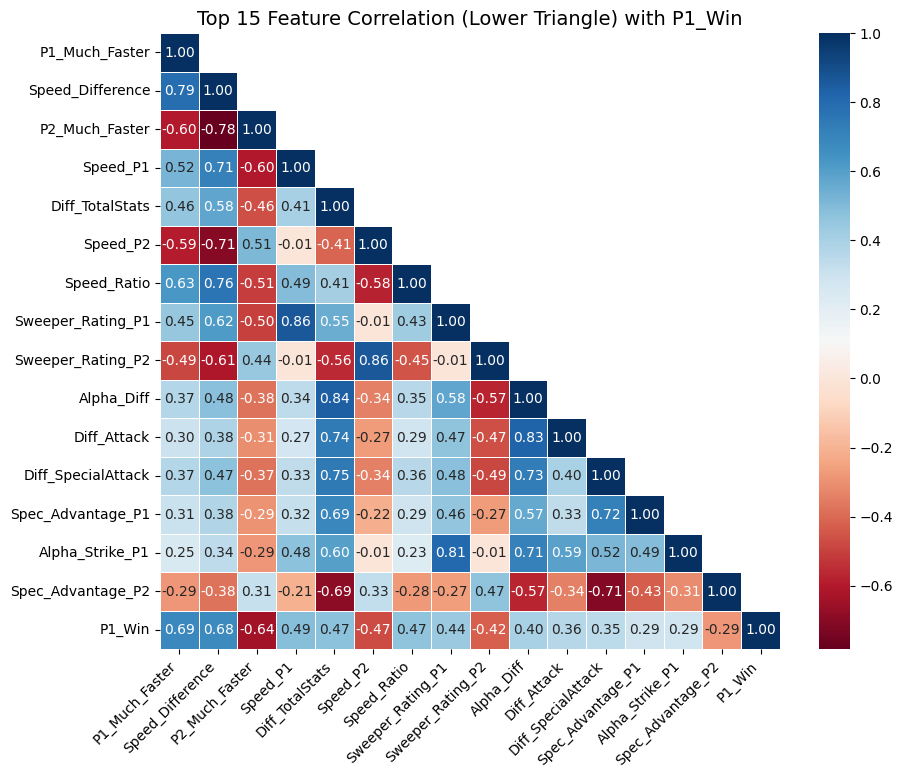

In [65]:
y_train_df = y_train.to_frame(name='P1_Win')
combined_df = pd.concat([X_train.select_dtypes(include=[np.number]), y_train_df], axis=1)

corr_matrix = combined_df.corr()

target_corr = corr_matrix['P1_Win'].sort_values(ascending=False, key=abs)
top_features = target_corr.index[1:16].tolist() 

corr_top = combined_df[top_features + ['P1_Win']].corr()

mask = np.triu(np.ones_like(corr_top, dtype=bool), k=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_top,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdBu',
    linewidths=.5
)

plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Feature Correlation (Lower Triangle) with P1_Win', fontsize=14)
plt.show()

Nhìn chung không có cặp biến nào tương quan quá mạnh với nhau (>0.9)  
Có hai biến tương quan khá mạnh với P1_Win là P1_Much_Faster và Speed_Difference, đều là hai biến về tốc độ -> tốc độ có thể có ảnh hưởng lớn đến dự đoán pokemon chiến thắng


## **TRAINING MODEL**

 30 đặc trưng quan trọng nhất đã được chọn:
                Feature  Importance
74          Speed_Ratio    0.219909
73     Speed_Difference    0.219078
75       P1_Much_Faster    0.078096
76       P2_Much_Faster    0.072026
1              Speed_P1    0.042938
35             Speed_P2    0.039210
26    Sweeper_Rating_P1    0.030811
60    Sweeper_Rating_P2    0.025935
90          Diff_Attack    0.018818
88      Diff_TotalStats    0.016804
72           Alpha_Diff    0.011859
69    Phys_Advantage_P2    0.009088
68    Phys_Advantage_P1    0.008892
70    Spec_Advantage_P1    0.007954
71    Spec_Advantage_P2    0.007226
87   Diff_SpecialAttack    0.007056
95         Ability_Diff    0.006877
84    Bulk_Advantage_P1    0.006840
24      Alpha_Strike_P1    0.006436
31         Tank_Bias_P1    0.006379
25  Durability_Score_P1    0.006334
65         Tank_Bias_P2    0.006288
58      Alpha_Strike_P2    0.006284
85              Diff_Hp    0.005968
94     Ability_Score_P2    0.005853
93     Ability_Score

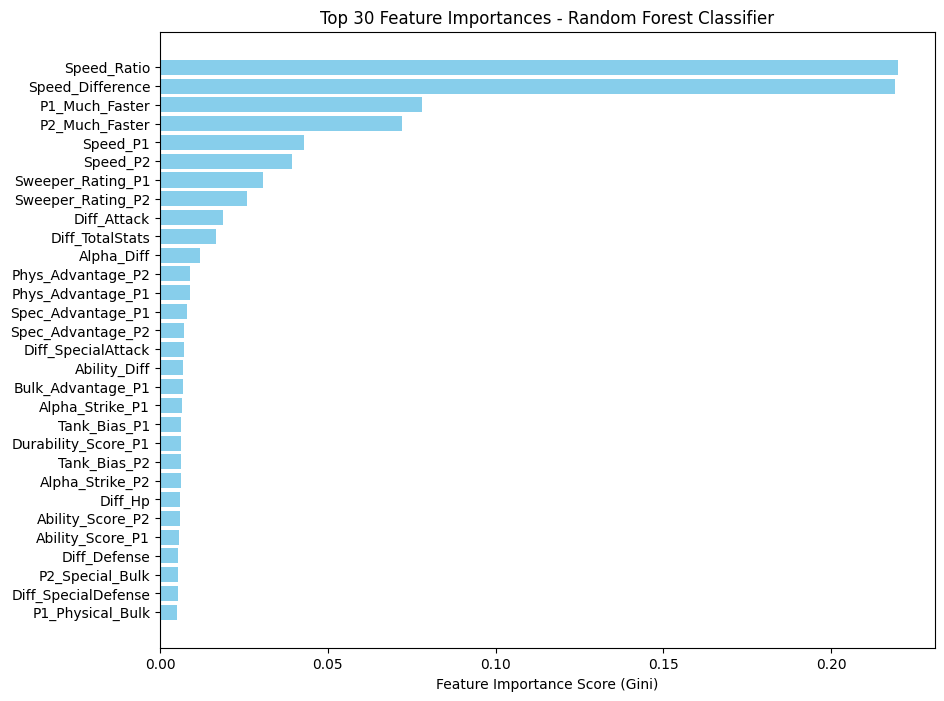

In [66]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 2. Thu thập và sắp xếp Feature Importances
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

# Sắp xếp giảm dần và chọn TOP 30 đặc trưng
TOP_N = 30
top_features_df = importances.sort_values(by="Importance", ascending=False).head(TOP_N)

selected_features = top_features_df["Feature"].tolist()

print(f" {TOP_N} đặc trưng quan trọng nhất đã được chọn:")
print(top_features_df)


plt.figure(figsize=(10, 8))
plt.barh(top_features_df["Feature"], top_features_df["Importance"], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance Score (Gini)")
plt.title(f"Top {TOP_N} Feature Importances - Random Forest Classifier")
plt.show()

Model                | Train Acc  | Test Acc   | Gap (Diff)
------------------------------------------------------------
Logistic Regression  | 0.8619     | 0.8564     | 0.0055
Random Forest        | 0.9580     | 0.9489     | 0.0091
XGBoost              | 0.9689     | 0.9594     | 0.0095


C:\Users\Administrator\AppData\Local\Temp\ipykernel_5600\3119980366.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test Acc', data=res_df, palette='viridis', label='Test Accuracy')


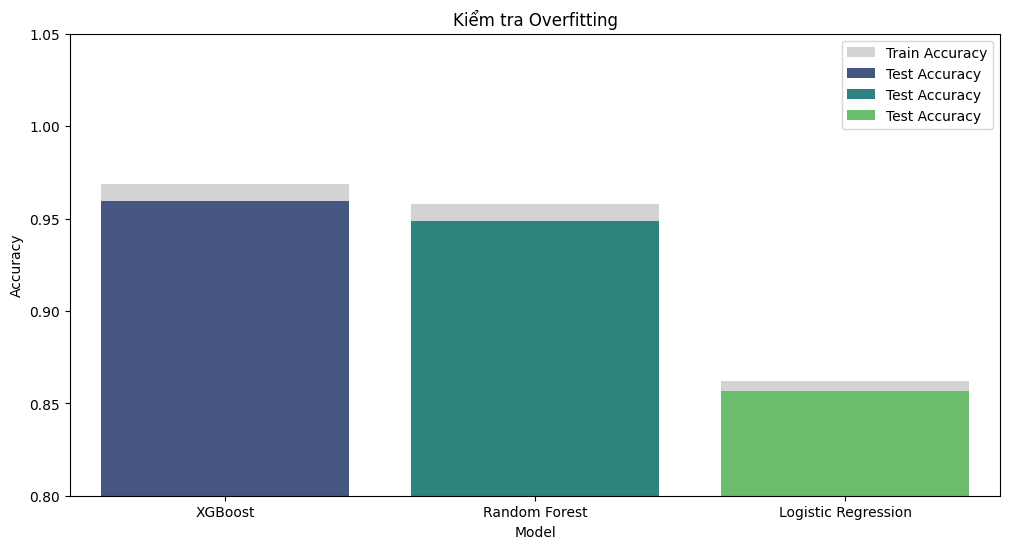

In [67]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_robust = RandomForestClassifier(
    n_estimators=200,          
    max_depth=12,             
    min_samples_leaf=4,       
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
xgb_robust = XGBClassifier(
    n_estimators=1000,          
    learning_rate=0.01,        
    max_depth=5,               
    subsample=0.8,             
    colsample_bytree=0.8,     
    gamma=1,                  
    reg_alpha=0.1,            
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
    )

# 2. KHỞI TẠO CÁC MODEL
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": rf_robust,
    "XGBoost": xgb_robust
}

# TRAINING & EVALUATION
results = []

print(f"{'Model':<20} | {'Train Acc':<10} | {'Test Acc':<10} | {'Gap (Diff)':<10}")
print("-" * 60)

for name, model in models.items():
    if name == "Logistic Regression":
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test
        
    model.fit(X_tr, y_train)
    
    # ĐÁNH GIÁ TRÊN TẬP TRAIN 
    y_train_pred = model.predict(X_tr)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    
    # ĐÁNH GIÁ TRÊN TẬP TEST
    y_test_pred = model.predict(X_te)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    # Tính Gap (Độ lệch)
    gap = train_acc - test_acc
    
    results.append({
        'Model': name, 
        'Train Acc': train_acc, 'Test Acc': test_acc, 'Gap': gap,
        'Train F1': train_f1, 'Test F1': test_f1
    })
    
    print(f"{name:<20} | {train_acc:.4f}     | {test_acc:.4f}     | {gap:.4f}")

res_df = pd.DataFrame(results).sort_values(by='Test Acc', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Train Acc', data=res_df, color='lightgray', label='Train Accuracy')

sns.barplot(x='Model', y='Test Acc', data=res_df, palette='viridis', label='Test Accuracy')
plt.title('Kiểm tra Overfitting')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.05) 
plt.legend()
plt.show()